In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("used_phone.csv")

In [3]:
df

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567
1,Oppo,OPPO A58 5G,6,128,Fair,69,1,13999,5216
2,OnePlus,OnePlus Nord N30 SE 5G,4,128,Like New,69,1,13999,7824
3,Redmi,POCO X5 Pro 5G,6,128,Fair,87,3,20999,7673
4,Realme,Realme Narzo 60x 5G,6,128,Fair,82,1,12999,5755
...,...,...,...,...,...,...,...,...,...
4995,Motorola,Motorola Edge 30 Ultra,12,256,Fair,77,1,49999,20789
4996,OnePlus,OnePlus 10R 5G,8,128,Fair,55,4,32999,6533
4997,Vivo,Vivo Y16,3,64,Like New,88,3,8999,4989
4998,Redmi,Redmi A3,3,64,Good,76,2,6999,3191


In [4]:
df.shape

(5000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand           5000 non-null   object
 1   model           5000 non-null   object
 2   ram_gb          5000 non-null   int64 
 3   storage_gb      5000 non-null   int64 
 4   condition       5000 non-null   object
 5   battery_health  5000 non-null   int64 
 6   age_years       5000 non-null   int64 
 7   original_price  5000 non-null   int64 
 8   resale_price    5000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 351.7+ KB


In [6]:
df.isnull().sum()

brand             0
model             0
ram_gb            0
storage_gb        0
condition         0
battery_health    0
age_years         0
original_price    0
resale_price      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(99)

In [8]:
df = df.drop_duplicates()
df = df.reset_index(drop=True) # 0,1,2,3,4,5

In [9]:
df.shape

(4901, 9)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567
1,Oppo,OPPO A58 5G,6,128,Fair,69,1,13999,5216
2,OnePlus,OnePlus Nord N30 SE 5G,4,128,Like New,69,1,13999,7824
3,Redmi,POCO X5 Pro 5G,6,128,Fair,87,3,20999,7673
4,Realme,Realme Narzo 60x 5G,6,128,Fair,82,1,12999,5755


object data converted into numerical with sklearn labelencoder
brand
model
condition

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le_brand = LabelEncoder() # instead
le_model = LabelEncoder()
le_condition = LabelEncoder()

In [14]:
df["brand"] = le_brand.fit_transform(df["brand"])
df["model"] = le_model.fit_transform(df["model"])
df["condition"] = le_condition.fit_transform(df["condition"])

In [15]:
df['brand']

0       7
1       4
2       3
3       6
4       5
       ..
4896    2
4897    3
4898    8
4899    6
4900    0
Name: brand, Length: 4901, dtype: int64

In [16]:
df["model"]

0         8
1        54
2        79
3        84
4       103
       ... 
4896     27
4897     70
4898    127
4899    111
4900    161
Name: model, Length: 4901, dtype: int64

In [17]:
df["condition"]

0       2
1       0
2       2
3       0
4       0
       ..
4896    0
4897    0
4898    2
4899    1
4900    0
Name: condition, Length: 4901, dtype: int64

In [18]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,7,8,8,256,2,61,2,39999,17567
1,4,54,6,128,0,69,1,13999,5216
2,3,79,4,128,2,69,1,13999,7824
3,6,84,6,128,0,87,3,20999,7673
4,5,103,6,128,0,82,1,12999,5755


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4901 entries, 0 to 4900
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   brand           4901 non-null   int64
 1   model           4901 non-null   int64
 2   ram_gb          4901 non-null   int64
 3   storage_gb      4901 non-null   int64
 4   condition       4901 non-null   int64
 5   battery_health  4901 non-null   int64
 6   age_years       4901 non-null   int64
 7   original_price  4901 non-null   int64
 8   resale_price    4901 non-null   int64
dtypes: int64(9)
memory usage: 344.7 KB


# Divided into independent & depending variable

In [20]:
x = df.drop("resale_price", axis=1)
y = df["resale_price"]

In [21]:
x.head(2)

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price
0,7,8,8,256,2,61,2,39999
1,4,54,6,128,0,69,1,13999


In [22]:
y.head(2)

0    17567
1     5216
Name: resale_price, dtype: int64

# Train Test split

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
print("The x train shape  : ", x_train.shape)
print("The x test shape   : ", x_test.shape)
print("The y train shape  : ", y_train.shape)
print("The y test shape   : ", y_test.shape)

The x train shape  :  (3920, 8)
The x test shape   :  (981, 8)
The y train shape  :  (3920,)
The y test shape   :  (981,)


# Training The MOdel Random Forest Regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)

In [27]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_pred = model.predict(x_test)
y_pred

array([20864.68,  5350.13,  3147.82,  1967.11,  4346.66, 36262.49,
       58638.83, 10017.5 , 19818.79, 30406.05, 73677.26,  8516.37,
        7531.76, 13978.43,  3380.54, 18045.56, 14466.85,  3556.2 ,
        4132.68,  8008.64,  6799.01,  3645.39,  3788.13, 49811.89,
        4417.74, 10316.08,  2990.01, 29529.15,  7733.97,  7026.38,
        4719.92,  8771.24,  9847.35, 19982.12, 24623.7 , 17128.5 ,
        6705.62,  4067.26,  5214.48,  1801.51,  2578.76,  7627.59,
        3692.45, 17688.28,  4112.05, 10364.88,  6221.39,  8917.09,
       75046.91,  2293.81, 24050.88, 44810.88, 12073.62, 28256.35,
        2236.32,  1493.62, 13868.58, 17710.68, 15962.51, 12210.76,
       26272.76,  7732.4 ,  6903.4 , 23647.13,  2631.38,  3763.32,
       15723.52,  8655.96,  7835.6 ,  3944.43,  7166.38,  5093.12,
       12451.75,  3226.31, 28318.73,  7416.26,  3168.96, 22708.41,
       30158.01, 56934.95,  2684.05,  1798.97,  4545.9 ,  3834.72,
        5831.46, 15832.35,  2988.44, 24746.47,  2670.  , 38672

# Performance Matrix

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("The R2 Score : ", r2)
print("The MAE Score : ", mae)
print("The MSE Score : ", mse)
print("The RMSE Score : ", rmse)

The R2 Score :  0.9872939706458711
The MAE Score :  758.3131090723751
The MSE Score :  3051339.050432416
The RMSE Score :  1746.808246612208


In [30]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,7,8,8,256,2,61,2,39999,17567
1,4,54,6,128,0,69,1,13999,5216
2,3,79,4,128,2,69,1,13999,7824
3,6,84,6,128,0,87,3,20999,7673
4,5,103,6,128,0,82,1,12999,5755


In [31]:
model.predict([[7,8,8,256,2,61,2,39999 ]])

c:\Users\MY PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([17398.04])

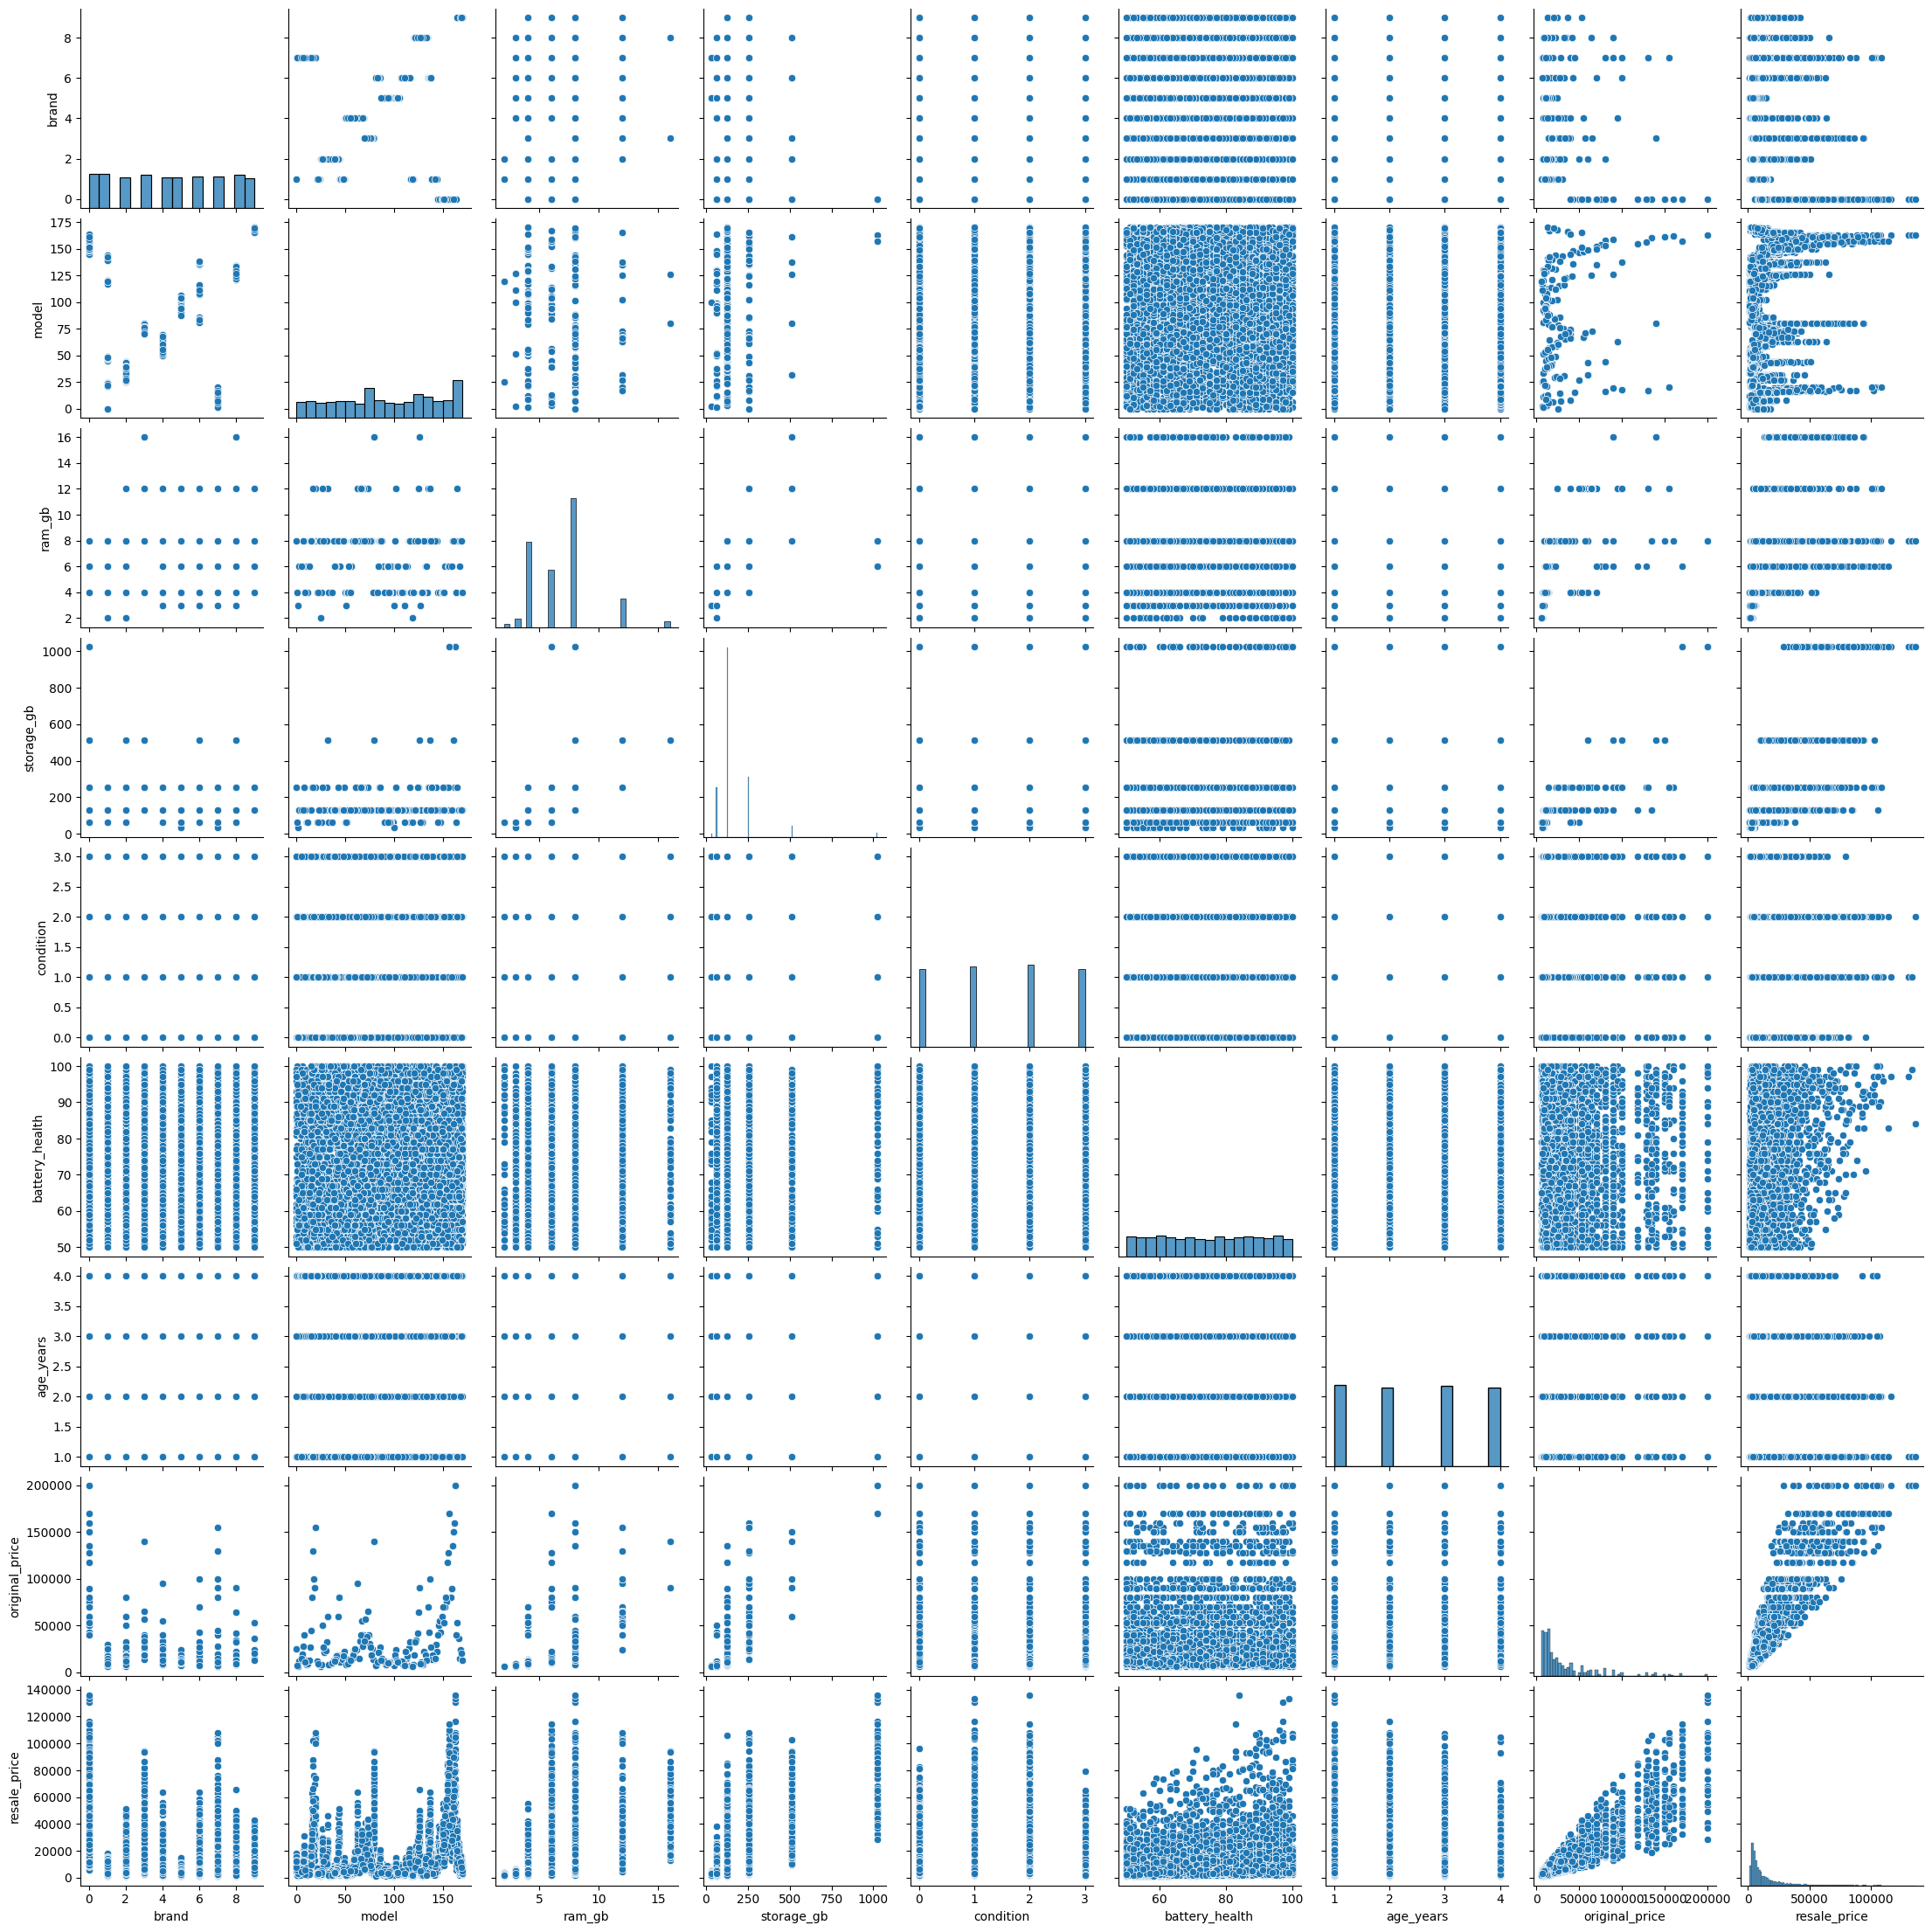

In [32]:
# Affect resale_price based on data
import seaborn as sns
sns.pairplot(df)

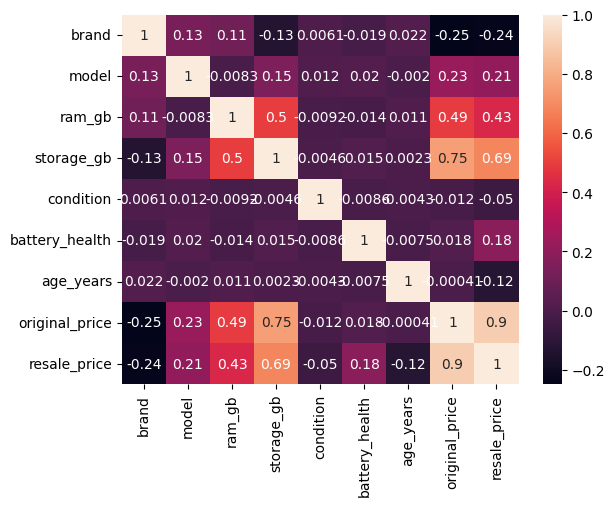

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(), annot=True)
plt.show()

 # pickle

In [34]:
import pickle
with open("model_phone.pkl", "wb") as f:
    pickle.dump(model, f)